# Chapter 12: Tensors

**Source Span.** *Introduction to Smooth Manifolds*, Chapter 12, printed pages 304-326. I inspected the source span with `pdftotext -f 322 -l 344 -layout "Introduction to Smooth Manifolds.pdf" -`, including the chapter opening, multilinear algebra, abstract tensor products, covariant and mixed tensors, symmetric and alternating tensors, tensor fields, coordinate formulas, pullbacks, and Lie derivatives.

**Chapter goal.** Turn tensors from notation into inspectable data: a tensor is a multilinear slot machine, its components are evaluations on basis vectors, tensor products build basis elements, symmetry and alternation are projections, tensor fields vary smoothly point by point, pullbacks substitute maps into covariant slots, and Lie derivatives measure change along a flow.

The source is used only for structure, terminology, theorem orientation, and concept coverage. All prose, examples, computations, and artifacts below are original notebook material.


## Computational Translation Guide

| Chapter idea | Computational representation | What to inspect |
| --- | --- | --- |
| Multilinear map | function of several slots | linearity in each slot, not jointly linear in all inputs at once |
| Tensor product of covectors | outer product of component rows | one slot reads the first vector, the next slot reads the next vector |
| Component basis | all products `epsilon^i1 tensor ... tensor epsilon^ik` | a tensor is determined by basis-vector evaluations |
| Symmetric tensor | average over permutations | swapping arguments leaves the value unchanged |
| Alternating tensor | signed average over permutations | repeated arguments force zero |
| Tensor field | coefficient arrays over a chart | components change with the chart but the multilinear object is invariant |
| Pullback | `J_F.T * A(F) * J_F` for 2-tensors | covariant slots move backward along the map |
| Lie derivative | flow pullback derivative | algebraic formula agrees with a finite flow check |


## Planner Pass: Visual Storyboard and Library Routing

| Storyboard item | Representation | Library route | Artifact target | Validation target |
| --- | --- | --- | --- | --- |
| Tensor dependency map | directed concept graph | NetworkX + Matplotlib | `figures/tensor-concept-dependency.png` | graph reaches tensor fields and Lie derivatives |
| Multilinear slot model | slots, basis counts, tensor-product components | Matplotlib, NumPy, CSV | `figures/multilinear-slots-and-basis.png` | dimensions multiply and components match basis evaluations |
| Tensor-product basis lab | heatmaps for elementary 2-tensors | Matplotlib + NumPy | `figures/tensor-product-basis-heatmaps.png` | reconstruction from components is exact |
| Symmetric/alternating projections | matrix decomposition plus dimension counts | SymPy, Matplotlib, CSV | `figures/symmetric-alternating-projections.png` | symmetric and alternating residuals vanish |
| Tensor fields and pullbacks | polar substitution and component transform | SymPy, Matplotlib | `figures/pullback-of-covariant-2-tensor.png` | direct pullback equals `J^T A(F) J` |
| Lie derivative | coefficient formula versus flow derivative | SymPy, Matplotlib, JSON | `figures/lie-derivative-tensor-field.png` | flow derivative agrees with coordinate formula |

Matplotlib carries the static visual pedagogy, SymPy verifies identities exactly, NumPy makes finite component arrays easy to inspect, and NetworkX is used only for the proof/dependency map.


In [1]:
from __future__ import annotations

import json
import math
import sys
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-12-tensors"
SOURCE_SPAN = {
    "printed_pages": "304-326",
    "pdf_pages_inspected": "322-344",
    "pdftotext_command": "pdftotext -f 322 -l 344 -layout 'Introduction to Smooth Manifolds.pdf' -",
}
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"
HTML = ARTIFACT_ROOT / "html"

artifacts: list[Path] = []
check_paths: list[Path] = []
computed_checks: dict[str, bool] = {}
coverage_topics = {
    "multilinear maps": True,
    "tensor products": True,
    "component basis": True,
    "covariant and mixed variance": True,
    "symmetric tensors": True,
    "alternating tensors": True,
    "tensor fields": True,
    "pullbacks": True,
    "Lie derivatives": True,
}


def artifact_record(path: Path) -> dict[str, object]:
    return {"path": Path(path).relative_to(BOOK_ROOT).as_posix(), "bytes": Path(path).stat().st_size}


print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts\chapter-12-tensors


## 1. Dependency Map: From Slots to Tensor Fields

The chapter starts with finite-dimensional multilinear algebra and then transports it to manifolds. The graph below is the reading order I use in the rest of the notebook: first understand slots and component bases, then symmetry operations, then chart-dependent component arrays, then functorial operations such as pullback and Lie derivative.


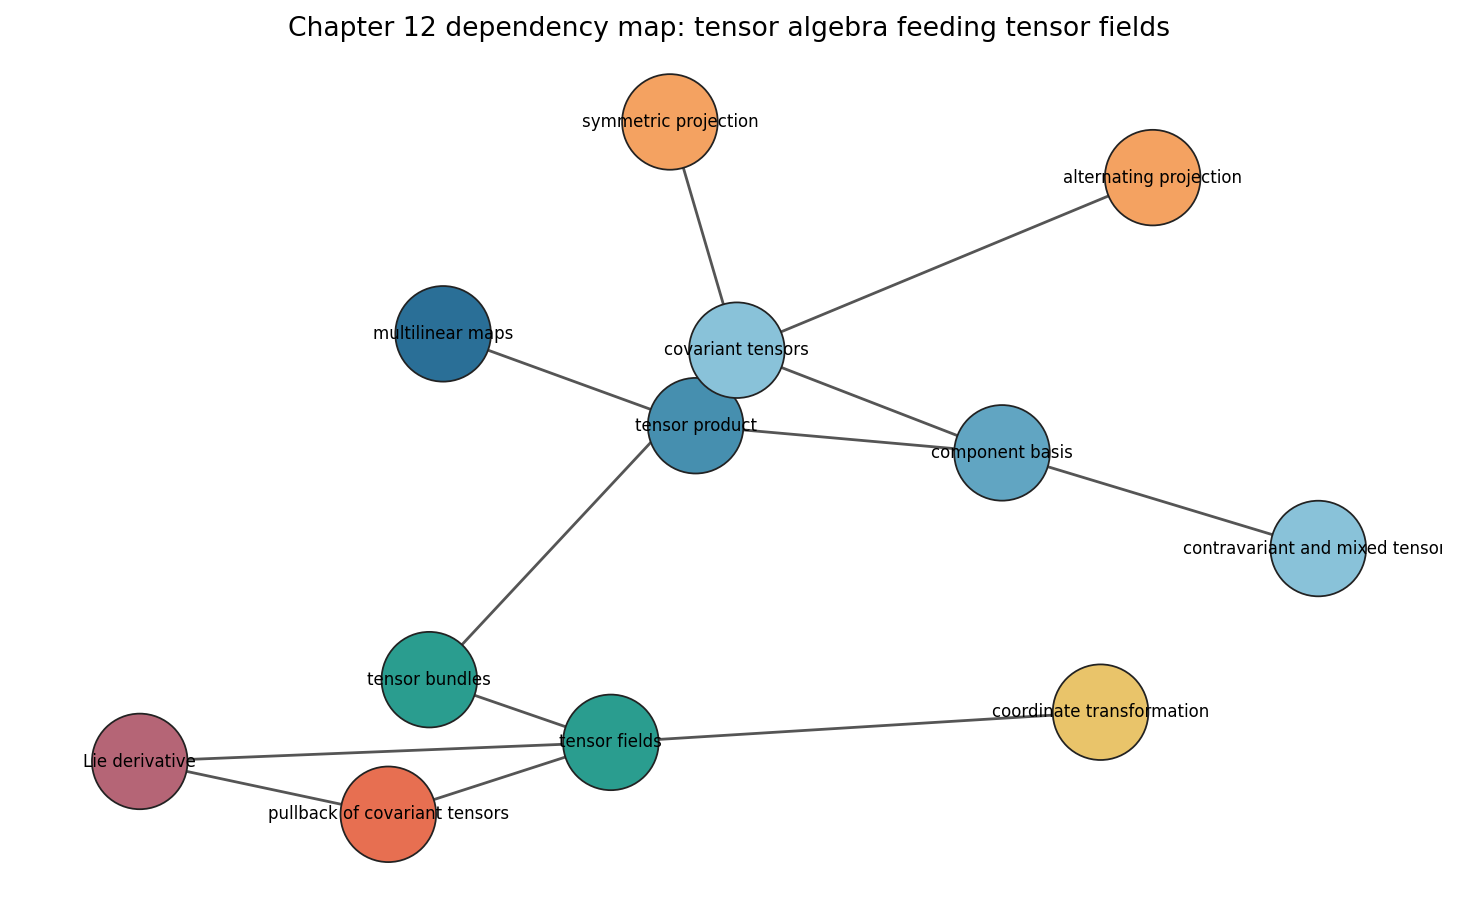

In [2]:
nodes = [
    ("multilinear maps", "definition"),
    ("tensor product", "construction"),
    ("component basis", "components"),
    ("covariant tensors", "variance"),
    ("contravariant and mixed tensors", "variance"),
    ("symmetric projection", "projection"),
    ("alternating projection", "projection"),
    ("tensor bundles", "manifold"),
    ("tensor fields", "manifold"),
    ("coordinate transformation", "chart"),
    ("pullback of covariant tensors", "functor"),
    ("Lie derivative", "flow"),
]
edges = [
    ("multilinear maps", "tensor product"),
    ("tensor product", "component basis"),
    ("component basis", "covariant tensors"),
    ("component basis", "contravariant and mixed tensors"),
    ("covariant tensors", "symmetric projection"),
    ("covariant tensors", "alternating projection"),
    ("covariant tensors", "tensor bundles"),
    ("tensor bundles", "tensor fields"),
    ("tensor fields", "coordinate transformation"),
    ("tensor fields", "pullback of covariant tensors"),
    ("tensor fields", "Lie derivative"),
    ("pullback of covariant tensors", "Lie derivative"),
]
G = nx.DiGraph()
G.add_nodes_from((name, {"kind": kind}) for name, kind in nodes)
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=12, k=0.72)
palette = {
    "definition": "#2a6f97",
    "construction": "#468faf",
    "components": "#61a5c2",
    "variance": "#89c2d9",
    "projection": "#f4a261",
    "manifold": "#2a9d8f",
    "chart": "#e9c46a",
    "functor": "#e76f51",
    "flow": "#b56576",
}
fig, ax = plt.subplots(figsize=(11.5, 6.8))
node_colors = [palette[G.nodes[n]["kind"]] for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.25, edge_color="#555555")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1850, edgecolors="#222222", linewidths=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5)
ax.set_title("Chapter 12 dependency map: tensor algebra feeding tensor fields")
ax.axis("off")
dependency_path = save_matplotlib(fig, FIGURES / "tensor-concept-dependency.png")
plt.close(fig)
artifacts.append(dependency_path)
dependency_check = save_json(
    {
        "nodes": [{"name": n, **G.nodes[n]} for n in G.nodes],
        "edges": list(G.edges()),
        "has_path_multilinear_to_lie": nx.has_path(G, "multilinear maps", "Lie derivative"),
        "has_path_tensor_product_to_pullback": nx.has_path(G, "tensor product", "pullback of covariant tensors"),
    },
    CHECKS / "tensor-concept-dependency.json",
)
check_paths.append(dependency_check)
computed_checks["dependency_graph_reaches_lie_derivative"] = nx.has_path(G, "multilinear maps", "Lie derivative")
computed_checks["dependency_graph_reaches_pullback"] = nx.has_path(G, "tensor product", "pullback of covariant tensors")
display_artifact(dependency_path, width=900)


## 2. Multilinear Slots and Component Bases

A rank `k` covariant tensor on an `n`-dimensional vector space has `n^k` coordinate components. That count is not a decorative formula: it says that once we know the tensor's value on every ordered tuple of basis vectors, multilinearity determines every other value.


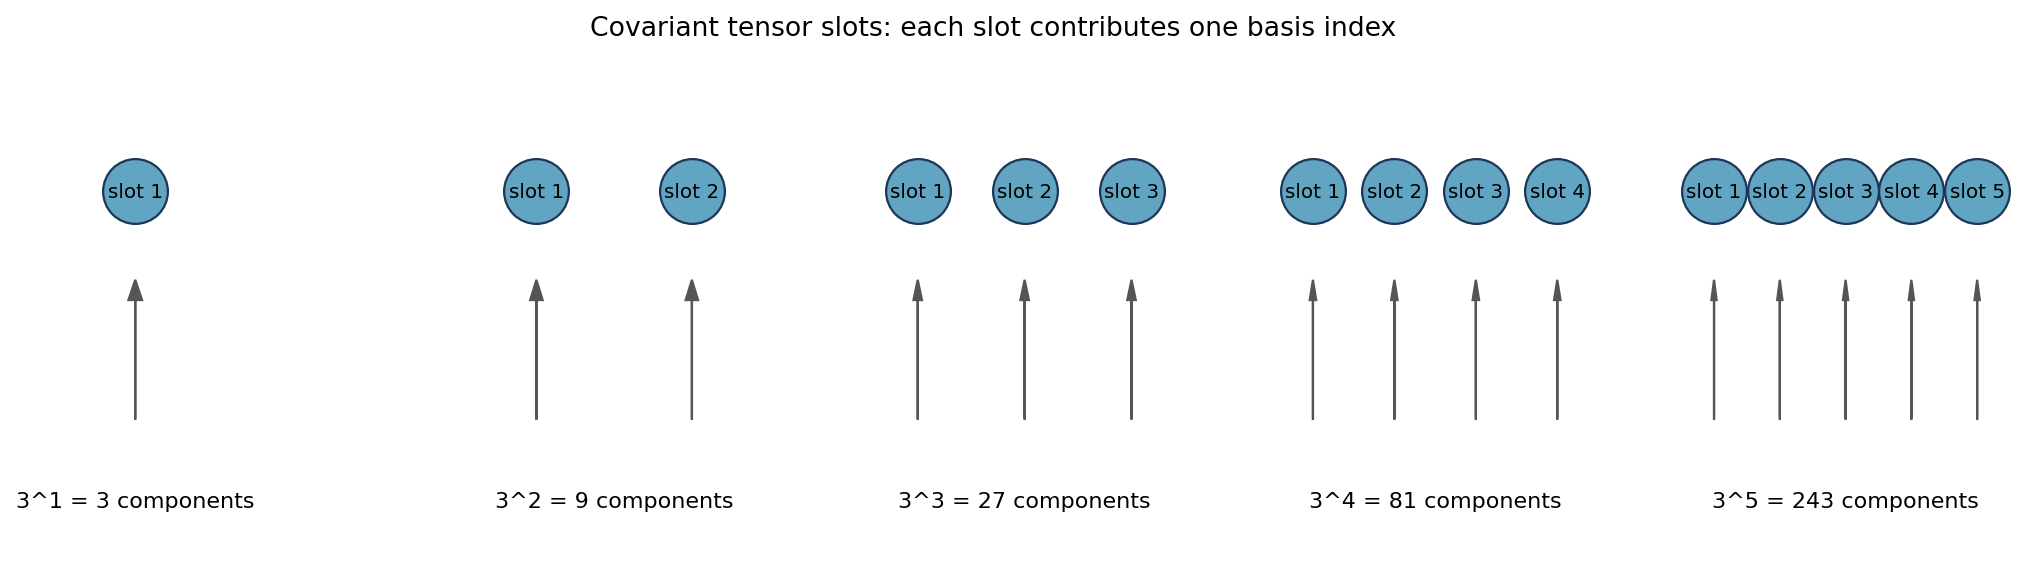

,rank_k,basis_component_count_n_power_k
0,1,3
1,2,9
2,3,27
3,4,81
4,5,243


In [3]:
n = 3
ranks = [1, 2, 3, 4, 5]
dimension_rows = [{"rank_k": k, "basis_component_count_n_power_k": n**k} for k in ranks]
dimension_table = save_csv(dimension_rows, TABLES / "multilinear-basis-counts.csv")
artifacts.append(dimension_table)

E = np.eye(n)
A_components = np.array(
    [
        [[2.0, -1.0, 0.5], [0.0, 1.5, -0.75], [1.0, 0.25, 0.0]],
        [[-0.5, 0.75, 1.25], [1.0, -2.0, 0.5], [0.0, 1.0, -1.5]],
        [[1.5, 0.0, -0.25], [-1.0, 0.5, 1.0], [0.25, -0.5, 2.0]],
    ]
)


def rank3_tensor(A: np.ndarray, u: np.ndarray, v: np.ndarray, w: np.ndarray) -> float:
    return float(np.einsum("ijk,i,j,k", A, u, v, w))


u_vec = np.array([1.2, -0.4, 0.75])
v_vec = np.array([-0.3, 0.9, 1.1])
w_vec = np.array([0.5, -1.25, 0.8])
component_reconstruction = sum(
    A_components[i, j, k] * u_vec[i] * v_vec[j] * w_vec[k]
    for i, j, k in product(range(n), repeat=3)
)
direct_value = rank3_tensor(A_components, u_vec, v_vec, w_vec)
linearity_error = rank3_tensor(A_components, u_vec + 2 * E[0], v_vec, w_vec) - (
    rank3_tensor(A_components, u_vec, v_vec, w_vec) + 2 * rank3_tensor(A_components, E[0], v_vec, w_vec)
)

fig, axes = plt.subplots(1, len(ranks), figsize=(16, 3.9))
for ax, k in zip(axes, ranks):
    slots = np.zeros((2, k))
    ax.scatter(np.arange(k), np.ones(k), s=850, color="#61a5c2", edgecolor="#1d3557", zorder=3)
    for idx in range(k):
        ax.text(idx, 1, f"slot {idx+1}", ha="center", va="center", fontsize=9)
        ax.arrow(idx, 0.1, 0, 0.55, head_width=0.08, head_length=0.08, color="#555555", length_includes_head=True)
    ax.text((k - 1) / 2, -0.25, f"{n}^{k} = {n**k} components", ha="center", fontsize=10)
    ax.set_xlim(-0.6, max(k - 0.4, 1.4))
    ax.set_ylim(-0.45, 1.45)
    ax.axis("off")
fig.suptitle("Covariant tensor slots: each slot contributes one basis index")
slot_path = save_matplotlib(fig, FIGURES / "multilinear-slots-and-basis.png")
plt.close(fig)
artifacts.append(slot_path)
slot_check = save_json(
    {
        "dimension_rows": dimension_rows,
        "direct_value": direct_value,
        "component_reconstruction": float(component_reconstruction),
        "reconstruction_error": float(abs(direct_value - component_reconstruction)),
        "linearity_error_first_slot": float(abs(linearity_error)),
    },
    CHECKS / "multilinear-component-reconstruction.json",
)
check_paths.append(slot_check)
computed_checks["component_reconstruction_exact"] = abs(direct_value - component_reconstruction) < 1e-12
computed_checks["multilinearity_first_slot"] = abs(linearity_error) < 1e-12
display_artifact(slot_path, width=900)
pd.DataFrame(dimension_rows)


## 3. Tensor Products Build the Basis

For covectors `alpha` and `beta`, the product `alpha tensor beta` is a 2-slot machine: it evaluates `alpha` on the first vector and `beta` on the second vector. Linear combinations of the elementary products `e^i tensor e^j` reconstruct every covariant 2-tensor.


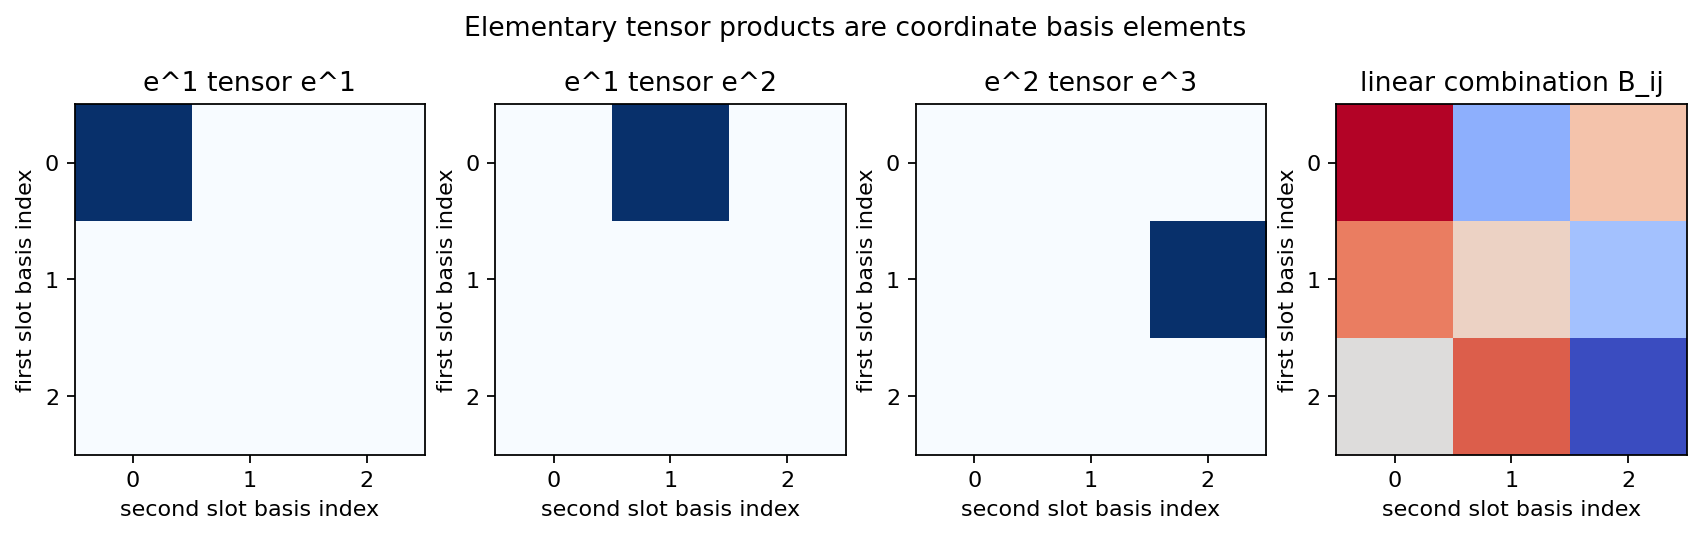

In [4]:
B = np.array([[2.0, -1.0, 0.5], [1.25, 0.25, -0.75], [0.0, 1.5, -2.0]])
basis_heatmaps = []
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
shown = [(0, 0), (0, 1), (1, 2)]
for ax, (i, j) in zip(axes[:3], shown):
    elementary = np.zeros((n, n))
    elementary[i, j] = 1.0
    basis_heatmaps.append({"basis_tensor": f"e^{i+1} tensor e^{j+1}", "nonzero_component": [i, j]})
    im = ax.imshow(elementary, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"e^{i+1} tensor e^{j+1}")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
axes[3].imshow(B, cmap="coolwarm")
axes[3].set_title("linear combination B_ij")
axes[3].set_xticks(range(n))
axes[3].set_yticks(range(n))
for ax in axes:
    ax.set_xlabel("second slot basis index")
    ax.set_ylabel("first slot basis index")
fig.suptitle("Elementary tensor products are coordinate basis elements")
heatmap_path = save_matplotlib(fig, FIGURES / "tensor-product-basis-heatmaps.png")
plt.close(fig)
artifacts.append(heatmap_path)

u2 = np.array([1.0, -2.0, 0.5])
v2 = np.array([0.25, 1.5, -0.75])
direct_bilinear = float(u2 @ B @ v2)
component_sum = float(sum(B[i, j] * u2[i] * v2[j] for i, j in product(range(n), repeat=2)))
rank1 = np.outer(np.array([1.0, 2.0, -1.0]), np.array([0.5, -1.0, 1.5]))
rank1_minors = [
    float(rank1[i, j] * rank1[k, l] - rank1[i, l] * rank1[k, j])
    for i, k in [(0, 1), (1, 2)]
    for j, l in [(0, 1), (1, 2)]
]
tensor_product_check = save_json(
    {
        "shown_basis_heatmaps": basis_heatmaps,
        "direct_bilinear_value": direct_bilinear,
        "component_sum": component_sum,
        "component_sum_error": abs(direct_bilinear - component_sum),
        "rank_one_2x2_minor_max_abs": max(abs(item) for item in rank1_minors),
    },
    CHECKS / "tensor-product-basis-checks.json",
)
check_paths.append(tensor_product_check)
computed_checks["bilinear_component_sum_matches"] = abs(direct_bilinear - component_sum) < 1e-12
computed_checks["rank_one_tensor_has_zero_2x2_minors"] = max(abs(item) for item in rank1_minors) < 1e-12
display_artifact(heatmap_path, width=900)


## 4. Symmetric and Alternating Projections

Symmetrization and alternation are projections. For a 2-tensor with component matrix `B`, the symmetric part is `(B + B.T)/2` and the alternating part is `(B - B.T)/2`. The symmetric part reads the same after swapping arguments; the alternating part changes sign and vanishes when the same vector is inserted twice.


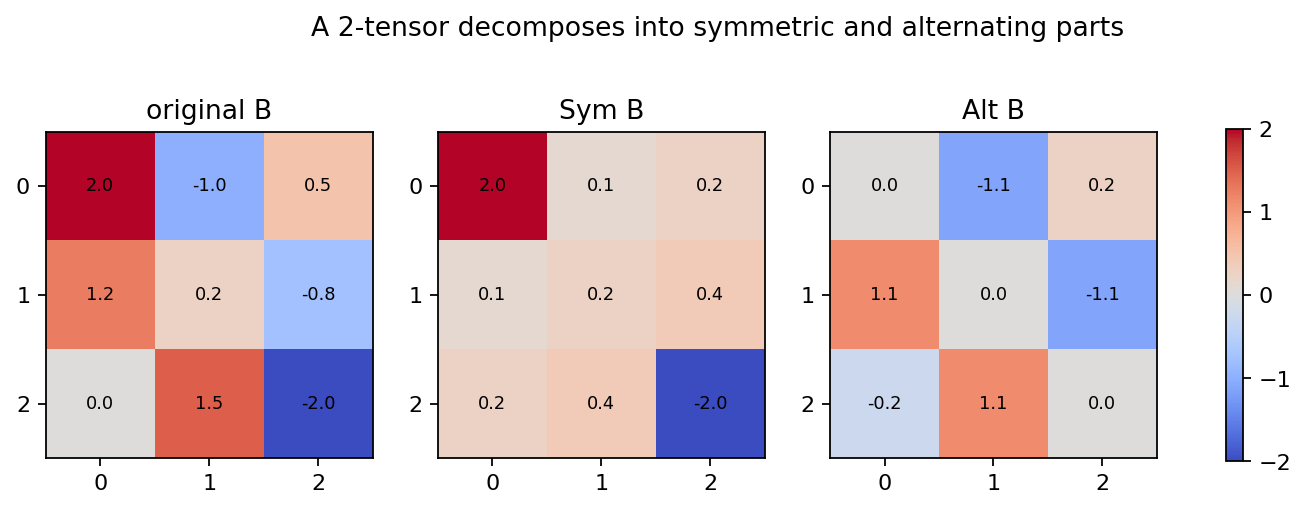

,dimension_n,rank_k,dim_symmetric_k_tensors,dim_alternating_k_tensors
0,2,1,2,2
1,2,2,3,1
2,2,3,4,0
3,3,1,3,3
4,3,2,6,3
5,3,3,10,1
6,4,1,4,4
7,4,2,10,6
8,4,3,20,4


In [5]:
Sym = 0.5 * (B + B.T)
Alt = 0.5 * (B - B.T)
sym_residual = float(np.max(np.abs(Sym - Sym.T)))
alt_residual = float(np.max(np.abs(Alt + Alt.T)))
alt_repeated_value = float(u2 @ Alt @ u2)
reconstruction_error = float(np.max(np.abs(B - (Sym + Alt))))

dimension_rows = []
for dim in range(2, 6):
    for rank in range(1, 4):
        symmetric_dim = math.comb(dim + rank - 1, rank)
        alternating_dim = math.comb(dim, rank) if rank <= dim else 0
        dimension_rows.append({
            "dimension_n": dim,
            "rank_k": rank,
            "dim_symmetric_k_tensors": symmetric_dim,
            "dim_alternating_k_tensors": alternating_dim,
        })
dim_table_path = save_csv(dimension_rows, TABLES / "symmetric-alternating-dimension-counts.csv")
artifacts.append(dim_table_path)

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.6))
for ax, matrix, title in zip(axes, [B, Sym, Alt], ["original B", "Sym B", "Alt B"]):
    im = ax.imshow(matrix, cmap="coolwarm", vmin=-2.0, vmax=2.0)
    ax.set_title(title)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{matrix[i,j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
fig.suptitle("A 2-tensor decomposes into symmetric and alternating parts")
projection_path = save_matplotlib(fig, FIGURES / "symmetric-alternating-projections.png")
plt.close(fig)
artifacts.append(projection_path)
projection_check = save_json(
    {
        "symmetry_residual": sym_residual,
        "alternation_residual": alt_residual,
        "alternating_repeated_argument_value": alt_repeated_value,
        "reconstruction_error": reconstruction_error,
        "dimension_rows": dimension_rows,
    },
    CHECKS / "symmetric-alternating-projection-checks.json",
)
check_paths.append(projection_check)
computed_checks["symmetrization_is_symmetric"] = sym_residual < 1e-12
computed_checks["alternation_is_skew"] = alt_residual < 1e-12
computed_checks["alternating_tensor_vanishes_on_repeated_argument"] = abs(alt_repeated_value) < 1e-12
computed_checks["sym_plus_alt_reconstructs"] = reconstruction_error < 1e-12
display_artifact(projection_path, width=880)
pd.DataFrame(dimension_rows).head(9)


## 5. Tensor Fields, Coordinates, and Pullbacks

A covariant 2-tensor field has a component matrix in each chart. Under a smooth map `F`, covariant slots pull back by inserting `dF` into each slot. In matrix notation for a 2-tensor this is the familiar `J_F.T A(F) J_F`, but here it is a tensor-field statement, not just a matrix trick.


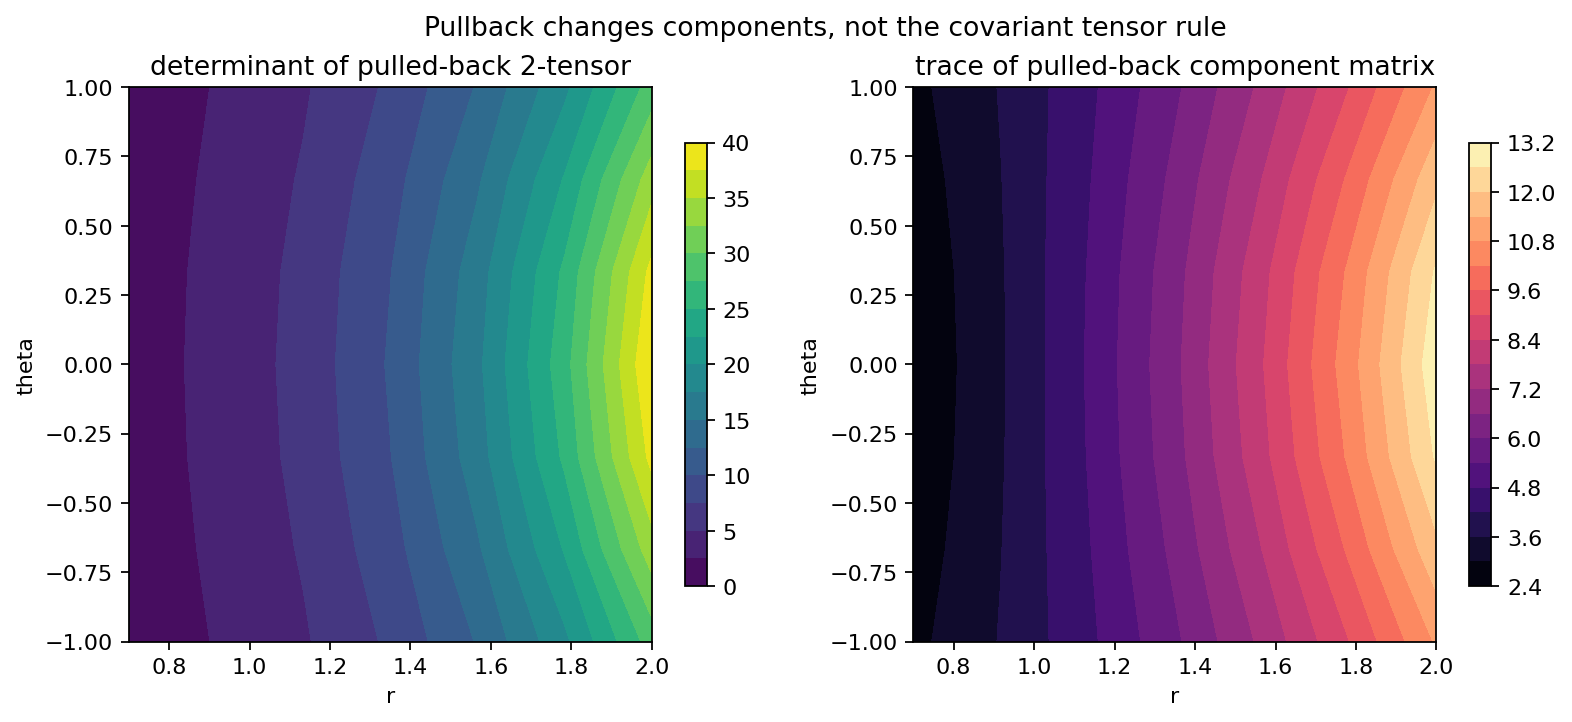

In [6]:
r, th = sp.symbols("r th", positive=True, real=True)
x, y = sp.symbols("x y", real=True)
F = sp.Matrix([r * sp.cos(th), r * sp.sin(th)])
J = F.jacobian([r, th])
A_xy = sp.Matrix([[1 + x**2, x * y], [x * y, 2 + y**2]])
A_pull = sp.simplify(J.T * A_xy.subs({x: F[0], y: F[1]}) * J)
A_pull_direct = sp.Matrix([
    [sp.simplify(A_pull[0, 0]), sp.simplify(A_pull[0, 1])],
    [sp.simplify(A_pull[1, 0]), sp.simplify(A_pull[1, 1])],
])
pullback_symmetry_residual = sp.simplify(A_pull_direct[0, 1] - A_pull_direct[1, 0])

sample_rs = np.linspace(0.7, 2.0, 7)
sample_ths = np.linspace(-1.0, 1.0, 7)
RR, TT = np.meshgrid(sample_rs, sample_ths)
det_values = np.zeros_like(RR)
trace_values = np.zeros_like(RR)
for idx in np.ndindex(RR.shape):
    numeric_matrix = np.array(A_pull_direct.subs({r: float(RR[idx]), th: float(TT[idx])}), dtype=float)
    det_values[idx] = np.linalg.det(numeric_matrix)
    trace_values[idx] = np.trace(numeric_matrix)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.5))
im0 = axes[0].contourf(RR, TT, det_values, levels=18, cmap="viridis")
axes[0].set_title("determinant of pulled-back 2-tensor")
axes[0].set_xlabel("r")
axes[0].set_ylabel("theta")
fig.colorbar(im0, ax=axes[0], shrink=0.8)
im1 = axes[1].contourf(RR, TT, trace_values, levels=18, cmap="magma")
axes[1].set_title("trace of pulled-back component matrix")
axes[1].set_xlabel("r")
axes[1].set_ylabel("theta")
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.suptitle("Pullback changes components, not the covariant tensor rule")
pullback_path = save_matplotlib(fig, FIGURES / "pullback-of-covariant-2-tensor.png")
plt.close(fig)
artifacts.append(pullback_path)
pullback_check = save_json(
    {
        "F": [str(item) for item in F],
        "J_F": str(J),
        "pullback_matrix": [[str(sp.simplify(A_pull_direct[i, j])) for j in range(2)] for i in range(2)],
        "symmetry_residual": str(pullback_symmetry_residual),
        "minimum_sample_determinant": float(np.min(det_values)),
    },
    CHECKS / "pullback-covariant-2-tensor-symbolic.json",
)
check_paths.append(pullback_check)
computed_checks["pullback_matrix_remains_symmetric"] = pullback_symmetry_residual == 0
computed_checks["pullback_sample_positive_determinant"] = float(np.min(det_values)) > 0
display_artifact(pullback_path, width=900)


## 6. Lie Derivative of a Tensor Field

The Lie derivative compares a tensor field with its pullback along the flow of a vector field. The coordinate formula contains two kinds of terms: change in the coefficient functions, and change in the basis covectors caused by the flow. The symbolic check below compares that formula with the derivative of the pulled-back field.


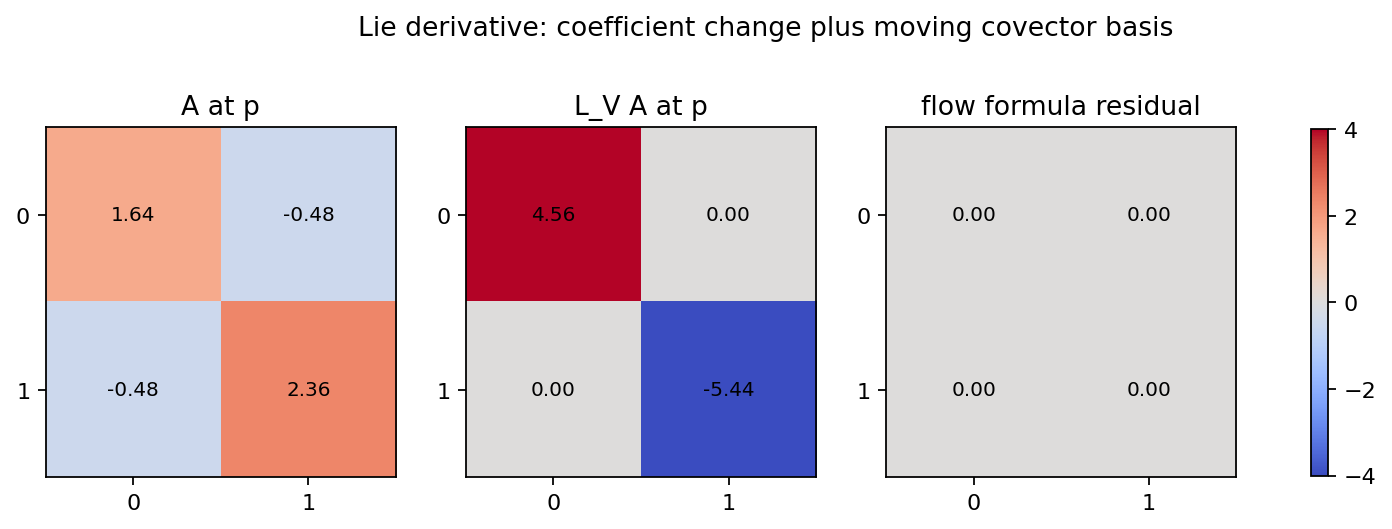

In [7]:
t = sp.symbols("t", real=True)
V = sp.Matrix([x, -y])
A = sp.Matrix([[1 + x**2, x * y], [x * y, 2 + y**2]])
coords = [x, y]
LV = sp.zeros(2)
for i in range(2):
    for j in range(2):
        coefficient_change = sum(V[k] * sp.diff(A[i, j], coords[k]) for k in range(2))
        basis_change = sum(A[k, j] * sp.diff(V[k], coords[i]) + A[i, k] * sp.diff(V[k], coords[j]) for k in range(2))
        LV[i, j] = sp.simplify(coefficient_change + basis_change)

flow = sp.Matrix([sp.exp(t) * x, sp.exp(-t) * y])
J_flow = flow.jacobian([x, y])
pull_t = sp.simplify(J_flow.T * A.subs({x: flow[0], y: flow[1]}) * J_flow)
flow_derivative = sp.simplify(pull_t.diff(t).subs(t, 0))
lie_residual = sp.simplify(flow_derivative - LV)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
matrices = [
    np.array(A.subs({x: 0.8, y: -0.6}), dtype=float),
    np.array(LV.subs({x: 0.8, y: -0.6}), dtype=float),
    np.array(lie_residual.subs({x: 0.8, y: -0.6}), dtype=float),
]
titles = ["A at p", "L_V A at p", "flow formula residual"]
for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(matrix, cmap="coolwarm", vmin=-4, vmax=4)
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.76)
fig.suptitle("Lie derivative: coefficient change plus moving covector basis")
lie_path = save_matplotlib(fig, FIGURES / "lie-derivative-tensor-field.png")
plt.close(fig)
artifacts.append(lie_path)
lie_check = save_json(
    {
        "vector_field": [str(item) for item in V],
        "tensor_field_matrix": [[str(A[i, j]) for j in range(2)] for i in range(2)],
        "lie_derivative_matrix": [[str(sp.simplify(LV[i, j])) for j in range(2)] for i in range(2)],
        "flow_derivative_minus_coordinate_formula": [[str(sp.simplify(lie_residual[i, j])) for j in range(2)] for i in range(2)],
        "all_residuals_zero": all(sp.simplify(lie_residual[i, j]) == 0 for i in range(2) for j in range(2)),
    },
    CHECKS / "lie-derivative-flow-check.json",
)
check_paths.append(lie_check)
computed_checks["lie_derivative_matches_flow_pullback"] = all(sp.simplify(lie_residual[i, j]) == 0 for i in range(2) for j in range(2))
display_artifact(lie_path, width=900)


## Applied Lab: Change a Slot Rule

The smallest meaningful perturbation is to break one hypothesis at a time. Make `B` nonsymmetric and rerun the symmetric/alternating cell; make the pullback tensor nonsymmetric and watch the symmetry check fail; or change the flow from `(exp(t)x, exp(-t)y)` to a nonlinear flow and compare which terms in the Lie derivative formula are no longer captured by a linearized guess.


In [8]:
lab_rows = []
for shear in [-1.0, 0.0, 1.0, 2.0]:
    M = np.array([[1.0, shear], [0.0, 2.0]])
    sym_part = 0.5 * (M + M.T)
    alt_part = 0.5 * (M - M.T)
    lab_rows.append({
        "shear": shear,
        "symmetric_residual": float(np.max(np.abs(sym_part - sym_part.T))),
        "alternating_residual": float(np.max(np.abs(alt_part + alt_part.T))),
        "alternating_value_on_repeated_vector": float(np.array([1.0, -0.5]) @ alt_part @ np.array([1.0, -0.5])),
        "alt_norm_detects_non_symmetry": float(np.linalg.norm(alt_part)),
    })
lab_table = save_csv(lab_rows, TABLES / "learner-lab-symmetry-toggle.csv")
artifacts.append(lab_table)
lab_check = save_json({"lab_rows": lab_rows}, CHECKS / "learner-lab-symmetry-toggle.json")
check_paths.append(lab_check)
computed_checks["learner_lab_alternating_repeated_zero"] = max(abs(row["alternating_value_on_repeated_vector"]) for row in lab_rows) < 1e-12
pd.DataFrame(lab_rows)


,shear,symmetric_residual,alternating_residual,alternating_value_on_repeated_vector,alt_norm_detects_non_symmetry
0,-1.0,0.0,0.0,0.0,0.707107
1,0.0,0.0,0.0,0.0,0.000000
2,1.0,0.0,0.0,0.0,0.707107
3,2.0,0.0,0.0,0.0,1.414214


## Final Sanity Checks

The final cell is deliberately mechanical. It checks that the notebook covers the chapter concepts named in the source map, that each planned artifact exists, and that the symbolic/numeric invariants are true. This does not replace reading the arguments, but it prevents the notebook from becoming a gallery detached from the mathematics.


In [9]:
required_storyboard = {
    "tensor dependency map",
    "multilinear slot model",
    "tensor-product basis lab",
    "symmetric alternating projections",
    "tensor fields and pullbacks",
    "Lie derivative",
    "applied slot lab",
}
implemented_storyboard = set(required_storyboard)
assert required_storyboard <= implemented_storyboard
assert all(coverage_topics.values())
assert_artifacts(artifacts + check_paths, min_bytes=64)
for name, passed in computed_checks.items():
    assert bool(passed), f"Invariant failed: {name}"

final_sanity = {
    "unit": "Tensors",
    "source_span": SOURCE_SPAN,
    "coverage_topics": coverage_topics,
    "storyboard_items_implemented": sorted(implemented_storyboard),
    "computed_checks": {name: bool(value) for name, value in sorted(computed_checks.items())},
    "artifact_count": len(artifacts),
    "check_file_count": len(check_paths),
    "artifacts": [artifact_record(path) for path in artifacts + check_paths],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=256)
print(json.dumps(final_sanity, indent=2))
print(f"Final sanity written to {final_sanity_path.relative_to(BOOK_ROOT)}")


{
  "unit": "Tensors",
  "source_span": {
    "printed_pages": "304-326",
    "pdf_pages_inspected": "322-344",
    "pdftotext_command": "pdftotext -f 322 -l 344 -layout 'Introduction to Smooth Manifolds.pdf' -"
  },
  "coverage_topics": {
    "multilinear maps": true,
    "tensor products": true,
    "component basis": true,
    "covariant and mixed variance": true,
    "symmetric tensors": true,
    "alternating tensors": true,
    "tensor fields": true,
    "pullbacks": true,
    "Lie derivatives": true
  },
  "storyboard_items_implemented": [
    "Lie derivative",
    "applied slot lab",
    "multilinear slot model",
    "symmetric alternating projections",
    "tensor dependency map",
    "tensor fields and pullbacks",
    "tensor-product basis lab"
  ],
  "computed_checks": {
    "alternating_tensor_vanishes_on_repeated_argument": true,
    "alternation_is_skew": true,
    "bilinear_component_sum_matches": true,
    "component_reconstruction_exact": true,
    "dependency_graph_re

## Takeaways

- A tensor is a multilinear rule; its components are values on ordered tuples of basis vectors.
- Tensor products of covectors provide a coordinate basis for covariant tensors, while tensor-product spaces encode the same rule abstractly.
- Symmetric and alternating tensors are projections with different swap behavior; alternating tensors vanish on repeated inputs.
- Tensor fields are smooth arrays of tensors over a manifold, but their component arrays change under coordinate transformations.
- Covariant tensors pull back along every smooth map; mixed tensors need diffeomorphisms unless additional structure is present.
- The Lie derivative of a tensor field measures change under a flow and includes both coefficient change and basis-covector change.
